# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

In [ ]:
# Keep exploratory cells permissive by default; final reported analyses should require complete seed sets.
EXP1_ONLY_COMPLETE_RUNS = True

# Missing test predictions are always generated automatically.
# Set this to True only when intentionally regenerating ALL test predictions.
RERUN_ALL_TEST_INFERENCE = True

In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess

import numpy as np
import pandas as pd

from visualize_utils import (
    compute_prediction_metrics,
    compute_seed_paired_drop,
    expected_prediction_for_checkpoint,
    find_selected_checkpoint,
    float_token_pattern,
    plot_mean_ci_curve,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
    warn_incomplete_seed_sets,
)

PROJECT_DATA_ROOT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo"
)

EXP1_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
EXP1_PYTHON = os.environ.get("EXP1_PYTHON", "python")
NETWORK = "mimic4models/keras_models/lstm.py"
EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXPECTED_EPOCHS = 100

EXP1_DATA_DIR = PROJECT_DATA_ROOT / "data/in-hospital-mortality"
EXP1_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP1_RESULTS_DIR = PROJECT_DATA_ROOT / "results/in-hospital-mortality"
EXP1_OUTPUT_DIR = EXP1_RESULTS_DIR / "plots"
EXP1_TIMESTEPS = [1, 2, 4, 8, 12, 24]



EXP1_EXPECTED_CONFIG = {
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_norm": False,
    "batch_size": 8,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "imputation": "previous",
    "prefix": "",
}

EXP1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible test predictions will be regenerated.")

Missing test predictions: AUTO-RUN
Rerun all existing test predictions: True


# Experiment 1 - Does measurement frequency matter?

## Experiment question and expected evidence

Question: Does prediction performance deteriorate when EHR measurements become sufficiently infrequent in the in-hospital mortality task?

Quantity: The figures below plot validation and test AUPRC/AUROC against temporal resolution. Error bars are mean across model seeds +/- 95% Student-t CI.

Evidence we are looking for: H1 is supported by relatively similar performance at fine resolutions followed by a meaningful decline at sufficiently coarse temporal resolution.

Caveat: Strict monotonic degradation is not required. Mild downsampling may have little effect or can look slightly better because of regularization or noise reduction. Validation AUPRC selects the checkpoint; AUROC and test metrics are read from that same selected epoch.

RERUN_ALL_TEST_INFERENCE=True
Regenerating existing prediction:
/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/1h/test_predictions/k_lstm.n16.d0.3.dep2.bs8.ts1.0.seed0.epoch95.test0.3215087160013621.state.csv
python -m mimic4models.in_hospital_mortality.main --mode test --network mimic4models/keras_models/lstm.py --data /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/data/in-hospital-mortality --output_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/1h --normalizer_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers/ihm_ts:1.00_impute:previous_start:zero_masks:True_n:15579.normalizer --load_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/1h/keras_states/k_l

,batch_norm,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,depth,dim,...,selected_validation_epoch,target_repl_coef,test_auprc,test_auroc,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,False,8,94,0.373447,94,/heinz-georgenas/users/mingzhul/Simultaneous-E...,95,True,2,16,...,94,0.0,0.301848,0.736431,1.0,0.373447,0.770488,0.770488,0.373447,0.770488
1,False,8,35,0.363009,35,/heinz-georgenas/users/mingzhul/Simultaneous-E...,36,True,2,16,...,35,0.0,0.283528,0.713501,1.0,0.363009,0.753016,0.753016,0.363009,0.753016
2,False,8,59,0.377469,59,/heinz-georgenas/users/mingzhul/Simultaneous-E...,60,True,2,16,...,59,0.0,0.292707,0.732991,1.0,0.377469,0.764679,0.764679,0.377469,0.764679
3,False,8,89,0.382345,89,/heinz-georgenas/users/mingzhul/Simultaneous-E...,90,True,2,16,...,89,0.0,0.292709,0.733889,1.0,0.382345,0.775329,0.775329,0.382345,0.775329
4,False,8,62,0.355122,62,/heinz-georgenas/users/mingzhul/Simultaneous-E...,63,True,2,16,...,62,0.0,0.285016,0.706086,1.0,0.355122,0.752636,0.752636,0.355122,0.752636
5,False,8,58,0.388768,58,/heinz-georgenas/users/mingzhul/Simultaneous-E...,59,True,2,16,...,58,0.0,0.302895,0.734724,2.0,0.388768,0.772463,0.772463,0.388768,0.772463
6,False,8,60,0.385208,60,/heinz-georgenas/users/mingzhul/Simultaneous-E...,61,True,2,16,...,60,0.0,0.307506,0.744196,2.0,0.385208,0.766522,0.766522,0.385208,0.766522
7,False,8,87,0.378108,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,True,2,16,...,87,0.0,0.300752,0.729683,2.0,0.378108,0.763186,0.763186,0.378108,0.763186
8,False,8,91,0.390922,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,2,16,...,91,0.0,0.302156,0.737082,2.0,0.390922,0.766076,0.766076,0.390922,0.766076
9,False,8,79,0.378478,79,/heinz-georgenas/users/mingzhul/Simultaneous-E...,80,True,2,16,...,79,0.0,0.299921,0.738666,2.0,0.378478,0.769356,0.769356,0.378478,0.769356



Experiment 1 missing exact test predictions
<none>

Experiment 1 validation AUPRC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.013742,0.384020,0.356537,0.370278,5,0.011067,0.004949,1.0
1,0.007263,0.391560,0.377034,0.384297,5,0.005850,0.002616,2.0
2,0.003310,0.377409,0.370789,0.374099,5,0.002666,0.001192,4.0
3,0.010158,0.380410,0.360094,0.370252,5,0.008181,0.003658,8.0
4,0.011828,0.375493,0.351837,0.363665,5,0.009526,0.004260,12.0
5,0.004797,0.349937,0.340342,0.345140,5,0.003864,0.001728,24.0



Experiment 1 validation AUROC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.012689,0.775918,0.750541,0.763230,5,0.010219,0.004570,1.0
1,0.004375,0.771896,0.763145,0.767521,5,0.003524,0.001576,2.0
2,0.002549,0.768333,0.763236,0.765784,5,0.002053,0.000918,4.0
3,0.004915,0.766221,0.756391,0.761306,5,0.003959,0.001770,8.0
4,0.008370,0.764583,0.747844,0.756214,5,0.006741,0.003014,12.0
5,0.002449,0.742534,0.737636,0.740085,5,0.001972,0.000882,24.0



Experiment 1 test AUPRC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.009104,0.300265,0.282058,0.291162,5,0.007332,0.003279,1.0
1,0.003669,0.306315,0.298977,0.302646,5,0.002955,0.001322,2.0
2,0.014882,0.307195,0.277430,0.292313,5,0.011986,0.005360,4.0
3,0.007049,0.295774,0.281677,0.288725,5,0.005677,0.002539,8.0
4,0.007087,0.287631,0.273458,0.280545,5,0.005707,0.002552,12.0
5,0.003722,0.279285,0.271842,0.275564,5,0.002997,0.001340,24.0



Experiment 1 test AUROC summary


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.017145,0.741724,0.707435,0.724579,5,0.013808,0.006175,1.0
1,0.006606,0.743476,0.730265,0.736870,5,0.005320,0.002379,2.0
2,0.006778,0.730383,0.716827,0.723605,5,0.005459,0.002441,4.0
3,0.003300,0.716538,0.709938,0.713238,5,0.002658,0.001189,8.0
4,0.004977,0.714530,0.704576,0.709553,5,0.004008,0.001793,12.0
5,0.006701,0.706140,0.692738,0.699439,5,0.005397,0.002413,24.0


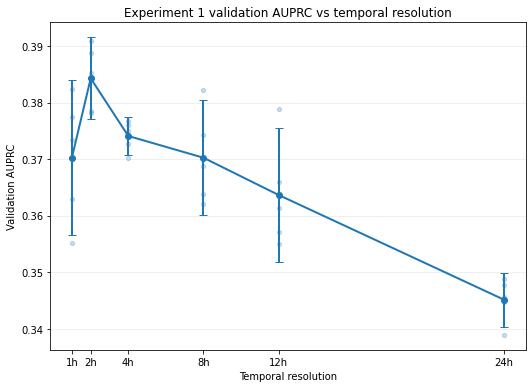

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_val_auprc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


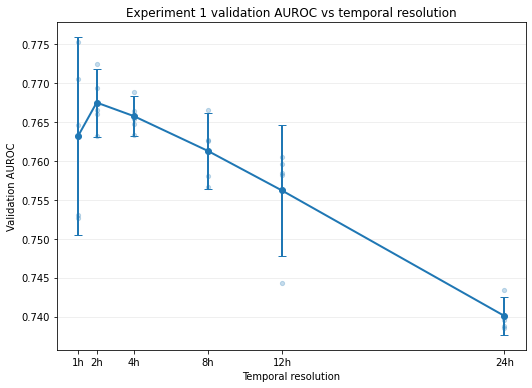

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_val_auroc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


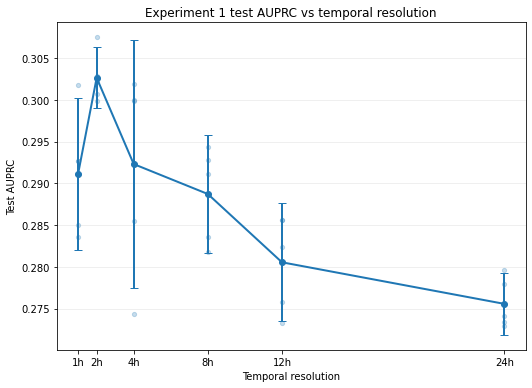

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_test_auprc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


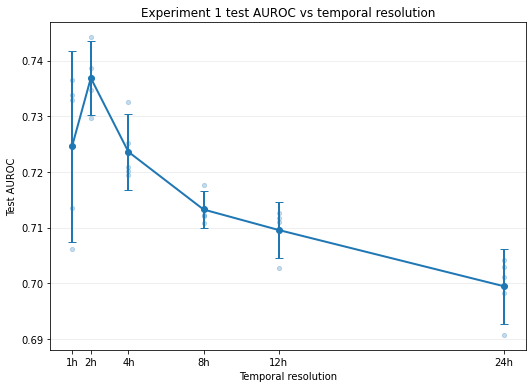

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/in-hospital-mortality/plots/experiment1_test_auroc_ci95.png
Error bars = 95% Student-t CI across model seeds; n=1 groups have undefined CI.


In [3]:
def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    return cast(value) if cast is not None else value


def parse_exp1_run(path):
    name = path.name
    m = re.search(float_token_pattern("ts") + r".*\.seed(\d+)(?:\.|$)", name)
    if m is not None:
        timestep = float(m.group(1))
        seed = int(m.group(2))
    else:
        m = re.search(r"seed(\d+)", name)
        if m is None:
            return None
        timestep = float(path.parent.parent.name.rstrip("h"))
        seed = int(m.group(1))
    return {
        "timestep": timestep,
        "seed": seed,
        "dim": _search(r"\.n(\d+)", name, int, EXP1_EXPECTED_CONFIG["dim"]),
        "depth": _search(r"\.dep(\d+)", name, int, EXP1_EXPECTED_CONFIG["depth"]),
        "dropout": _search(r"\.d([0-9]+(?:\.[0-9]+)?)(?=\.dep|\.|$)", name, float, EXP1_EXPECTED_CONFIG["dropout"]),
        "rec_dropout": _search(r"\.rd([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, EXP1_EXPECTED_CONFIG["rec_dropout"]),
        "batch_norm": re.search(r"\.bn(?=\.|$)", name) is not None,
        "batch_size": _search(r"\.bs(\d+)", name, int, EXP1_EXPECTED_CONFIG["batch_size"]),
        "l1": _search(r"\.L1([0-9.eE+-]+)(?=\.|$)", name, float, EXP1_EXPECTED_CONFIG["l1"]),
        "l2": _search(r"\.L2([0-9.eE+-]+)(?=\.|$)", name, float, EXP1_EXPECTED_CONFIG["l2"]),
        "target_repl_coef": _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, EXP1_EXPECTED_CONFIG["target_repl_coef"]),
    }


def find_exp1_normalizer(timestep):
    pattern = "ihm_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer".format(float(timestep))
    candidates = sorted(EXP1_NORMALIZER_DIR.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one Experiment 1 normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def exp1_timestep_dir(timestep):
    timestep = float(timestep)
    if timestep.is_integer():
        return "{}".format(int(timestep))
    return "{}".format(timestep)


def build_exp1_test_inference_command(run, checkpoint):
    output_dir = EXP1_RESULTS_DIR / "{}h".format(exp1_timestep_dir(run["timestep"]))
    cmd = [
        EXP1_PYTHON, "-m", "mimic4models.in_hospital_mortality.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(EXP1_DATA_DIR),
        "--output_dir", str(output_dir),
        "--normalizer_state", str(find_exp1_normalizer(run["timestep"])),
        "--load_state", str(checkpoint),
        "--timestep", str(float(run["timestep"])),
        "--seed", str(int(run["seed"])),
        "--dim", str(int(run["dim"])),
        "--depth", str(int(run["depth"])),
        "--dropout", str(run["dropout"]),
        "--rec_dropout", str(run["rec_dropout"]),
        "--batch_size", str(int(run["batch_size"])),
        "--optimizer", EXP1_EXPECTED_CONFIG["optimizer"],
        "--lr", str(EXP1_EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXP1_EXPECTED_CONFIG["beta_1"]),
        "--l1", str(run["l1"]),
        "--l2", str(run["l2"]),
        "--target_repl_coef", str(run["target_repl_coef"]),
        "--imputation", EXP1_EXPECTED_CONFIG["imputation"],
        "--prefix", EXP1_EXPECTED_CONFIG["prefix"],
    ]
    if run["batch_norm"]:
        cmd += ["--batch_norm", "True"]
    return cmd


def ensure_exp1_prediction(run, checkpoint, prediction_path):
    cmd = build_exp1_test_inference_command(run, checkpoint)
    if prediction_path.exists():
        if not RERUN_ALL_TEST_INFERENCE:
            return prediction_path
        print("RERUN_ALL_TEST_INFERENCE=True")
        print("Regenerating existing prediction:")
        print(prediction_path)
        print(quote_command(cmd))
    else:
        print("Missing test prediction; running inference:")
        print(prediction_path)
        print(quote_command(cmd))
    subprocess.check_call(cmd, cwd=str(EXP1_REPO_DIR))
    if not prediction_path.exists():
        raise RuntimeError("Test inference completed but exact prediction file is missing: {}".format(prediction_path))
    return prediction_path


exp1_rows = []
exp1_missing_predictions = []

for timestep in EXP1_TIMESTEPS:
    log_dir = EXP1_RESULTS_DIR / "{}h".format(timestep) / "keras_logs"
    if not log_dir.exists():
        print("Missing log directory:", log_dir)
        continue
    for log_path in sorted(log_dir.glob("*.seed*.csv")):
        run = parse_exp1_run(log_path)
        if run is None:
            print("Skipping unrecognized filename:", log_path.name)
            continue
        if abs(run["timestep"] - float(timestep)) > 1e-6 or run["seed"] not in EXPECTED_MODEL_SEEDS:
            continue
        best = read_validation_log(log_path, only_complete=EXP1_ONLY_COMPLETE_RUNS)
        if best is None:
            print("Skipping empty/incomplete run:", log_path.name)
            continue
        checkpoint = find_selected_checkpoint(log_path, best["best_csv_epoch"])
        prediction_path = None
        test_metrics = {"test_auroc": np.nan, "test_auprc": np.nan}
        if checkpoint is None:
            exp1_missing_predictions.append({**run, "reason": "missing selected checkpoint", "log_path": str(log_path)})
        else:
            prediction_path = expected_prediction_for_checkpoint(EXP1_RESULTS_DIR, "{}".format(timestep), checkpoint)
            ensure_exp1_prediction(run, checkpoint, prediction_path)
            test_metrics = compute_prediction_metrics(prediction_path)
        exp1_rows.append({
            **run,
            **best,
            "log_path": str(log_path),
            "checkpoint": None if checkpoint is None else str(checkpoint),
            "prediction_path": None if prediction_path is None else str(prediction_path),
            **test_metrics,
        })

exp1_runs = pd.DataFrame(exp1_rows).sort_values(["timestep", "seed"]).reset_index(drop=True)
exp1_missing_predictions = pd.DataFrame(exp1_missing_predictions)

show_table("Experiment 1 selected validation checkpoints and exact test provenance", exp1_runs, max_rows=200)
show_table("Experiment 1 missing exact test predictions", exp1_missing_predictions, max_rows=200)
warn_incomplete_seed_sets(exp1_runs, ["timestep"])

exp1_val_auprc_summary = summarize_with_t_ci(exp1_runs, ["timestep"], "val_auprc")
exp1_val_auroc_summary = summarize_with_t_ci(exp1_runs, ["timestep"], "val_auroc")
exp1_test_available = exp1_runs.dropna(subset=["test_auprc", "test_auroc"])
exp1_test_auprc_summary = summarize_with_t_ci(exp1_test_available, ["timestep"], "test_auprc")
exp1_test_auroc_summary = summarize_with_t_ci(exp1_test_available, ["timestep"], "test_auroc")

show_table("Experiment 1 validation AUPRC summary", exp1_val_auprc_summary)
show_table("Experiment 1 validation AUROC summary", exp1_val_auroc_summary)
show_table("Experiment 1 test AUPRC summary", exp1_test_auprc_summary)
show_table("Experiment 1 test AUROC summary", exp1_test_auroc_summary)

plot_mean_ci_curve(exp1_val_auprc_summary, "timestep", "Validation AUPRC", "Experiment 1 validation AUPRC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_val_auprc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_runs, raw_metric="val_auprc")
plot_mean_ci_curve(exp1_val_auroc_summary, "timestep", "Validation AUROC", "Experiment 1 validation AUROC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_val_auroc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_runs, raw_metric="val_auroc")

if len(exp1_test_available):
    plot_mean_ci_curve(exp1_test_auprc_summary, "timestep", "Test AUPRC", "Experiment 1 test AUPRC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_test_auprc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_test_available, raw_metric="test_auprc")
    plot_mean_ci_curve(exp1_test_auroc_summary, "timestep", "Test AUROC", "Experiment 1 test AUROC vs temporal resolution", EXP1_OUTPUT_DIR / "experiment1_test_auroc_ci95.png", EXP1_TIMESTEPS, xlabel="Temporal resolution", raw_df=exp1_test_available, raw_metric="test_auroc")
else:
    print("No exact validation-selected test predictions available for Experiment 1 plots.")

## Optional degradation relative to 1h

Question: How much performance is lost relative to the native 1h representation?

Quantity: Delta(r, s) = M(1h, s) - M(r, s) is computed within each model seed before summarizing across seeds. Error bars are 95% Student-t CIs across paired seed-level drops.

Evidence we are looking for: Positive degradation at coarse resolutions supports H1.

Caveat: This descriptive seed-level plot does not prove a patient-level paired test difference; it only summarizes run-to-run behavior across trained seeds.

In [4]:
exp1_test_drops = pd.DataFrame()
if len(exp1_test_available):
    exp1_test_drops = compute_seed_paired_drop(exp1_test_available, [], "timestep", 1.0, "test_auprc", drop_col="auprc_drop")
    exp1_test_drops = compute_seed_paired_drop(exp1_test_drops, [], "timestep", 1.0, "test_auroc", drop_col="auroc_drop")
    exp1_auprc_drop_summary = summarize_with_t_ci(exp1_test_drops, ["timestep"], "auprc_drop")
    exp1_auroc_drop_summary = summarize_with_t_ci(exp1_test_drops, ["timestep"], "auroc_drop")
    show_table("Experiment 1 test AUPRC drop from 1h", exp1_auprc_drop_summary)
    show_table("Experiment 1 test AUROC drop from 1h", exp1_auroc_drop_summary)
else:
    print("No Experiment 1 exact test predictions available for optional degradation summaries.")


Experiment 1 test AUPRC drop from 1h


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.000000,0.000000,0.000000,0.000000,5,0.000000,0.000000,1.0
1,0.010622,-0.000863,-0.022106,-0.011484,5,0.008554,0.003826,2.0
2,0.018974,0.017823,-0.020125,-0.001151,5,0.015281,0.006834,4.0
3,0.014491,0.016927,-0.012054,0.002436,5,0.011670,0.005219,8.0
4,0.015270,0.025887,-0.004653,0.010617,5,0.012298,0.005500,12.0
5,0.011138,0.026736,0.004460,0.015598,5,0.008970,0.004012,24.0



Experiment 1 test AUROC drop from 1h


,ci95,ci95_high,ci95_low,mean,n,sd,sem,timestep
0,0.000000,0.000000,0.000000,0.000000,5,0.000000,0.000000,1.0
1,0.022146,0.009855,-0.034436,-0.012291,5,0.017835,0.007976,2.0
2,0.021975,0.022950,-0.021001,0.000974,5,0.017698,0.007915,4.0
3,0.015722,0.027064,-0.004381,0.011341,5,0.012662,0.005663,8.0
4,0.019625,0.034652,-0.004599,0.015026,5,0.015806,0.007069,12.0
5,0.022077,0.047218,0.003063,0.025141,5,0.017781,0.007952,24.0
